In [1]:
# Automatic Google Colab setup: clones the repo to access the .py module
# and the dataset in this folder (no effect when run locally).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Base-Algorithms/02-MLP-Manual-Backpropagation")
    get_ipython().system('pip install -q openpyxl')


# MLP with Manual Backpropagation (1 hidden layer)

Translated from `Codigo01_Seno_MLP_Backpropagation.R`.

This notebook implements, with plain `numpy`, a one-hidden-layer
Multi-Layer Perceptron (MLP) trained via **backpropagation** (gradient
descent in matrix form), to fit a noisy sine function.

## Theory

Architecture: input (1 feature + bias) -> hidden layer (`n_hidden` neurons,
tanh activation) -> linear output (1 neuron).

**Forward pass:**

$$H = \tanh(XW_1), \qquad \hat{y} = HW_2 + b_2$$

**Cost function** (sum of squared errors):

$$SSE = \sum_i (y_i - \hat{y}_i)^2$$

**Backpropagation** (chain rule), in the matrix form used in the code:

$$\frac{\partial SSE}{\partial W_2} = -H^T e, \qquad
\frac{\partial SSE}{\partial b_2} = -\sum_i e_i, \qquad
\frac{\partial SSE}{\partial W_1} = -X^T\big[(eW_2^T)\odot(1-H^2)\big]$$

where $e = y - \hat{y}$ and $(1-H^2)$ is the derivative of $\tanh$. Weights
are updated in the direction opposite to the gradient, scaled by the
learning rate.

**Why does $(1-H^2)$ only show up in $W_1$'s gradient, and not in $W_2$'s?**
Follow the path each weight sits on: `input -> (X@W1) -> tanh -> H ->
(H@W2+b2) -> output`. Between $H$ and the output there is no activation at
all — it's a direct, linear step — so $W_2$'s gradient never passes through
an activation derivative. Between $X@W_1$ and the output, the path
**crosses** the $\tanh$, and by the chain rule, crossing a function means
multiplying by its local derivative — exactly $(1-H^2)$. General rule: any
weight sitting *before* an activation carries that activation's derivative
in its gradient; any weight *after* the last activation does not.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mlp_manual_backprop import (
    load_data, build_design_matrix, train_mlp, forward,
    identity_activation, identity_derivative,
)

plt.rcParams["figure.figsize"] = (7, 4.5)


## Data

100 points sampled from $y = \sin(x) + \text{noise}$.


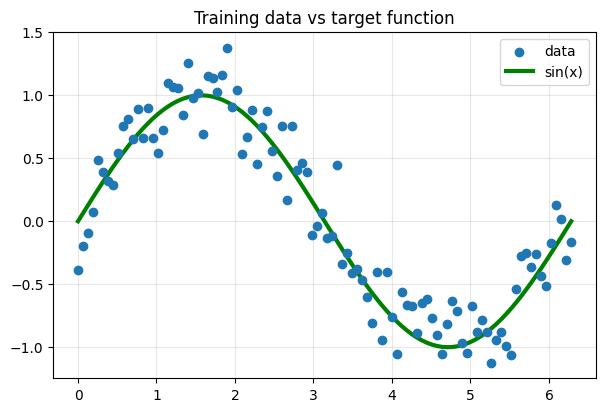

In [3]:
dt = load_data("data/Seno.xlsx")
x = dt["x"].to_numpy(dtype=float)
y_flat = dt["y"].to_numpy(dtype=float)

X = build_design_matrix(x)
y = y_flat.reshape(-1, 1)

plt.scatter(x, y_flat, color="tab:blue", label="data", zorder=3)
plt.plot(np.sort(x), np.sin(np.sort(x)), color="green", lw=3, label="sin(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Training data vs target function")
plt.show()


## Why does the non-linearity matter?

Before training, it's worth asking: what happens if we remove `tanh` from
the hidden layer (replace it with the identity function)? Mathematically,
`hidden = X @ w1` followed by `output = hidden @ w2 + b2` collapses into
`output = X @ (w1 @ w2) + b2` — **two stacked linear transformations are
still just one linear transformation**, no matter how many hidden neurons
you use. Without a non-linearity, the whole "network" is mathematically
equivalent to plain linear regression. Let's verify this empirically.


In [4]:
result_no_activation = train_mlp(
    X, y, n_hidden=6, learning_rate=0.01, n_steps=50_000, seed=42,
    activation=identity_activation, activation_derivative=identity_derivative,
)
result_tanh = train_mlp(X, y, n_hidden=6, learning_rate=0.01, n_steps=50_000, seed=42)

combined_weight = result_no_activation.weights.w1 @ result_no_activation.weights.w2
print(f"Final SSE without activation (identity): {result_no_activation.loss_history[-1]:.4f}")
print(f"Final SSE with tanh                    : {result_tanh.loss_history[-1]:.4f}")
print(f"Combined w1 @ w2 (collapses to a line's slope/intercept-like vector): {combined_weight.flatten()}")


Final SSE without activation (identity): 23.9208
Final SSE with tanh                    : 4.3684
Combined w1 @ w2 (collapses to a line's slope/intercept-like vector): [ 0.16961228 -0.28304893]


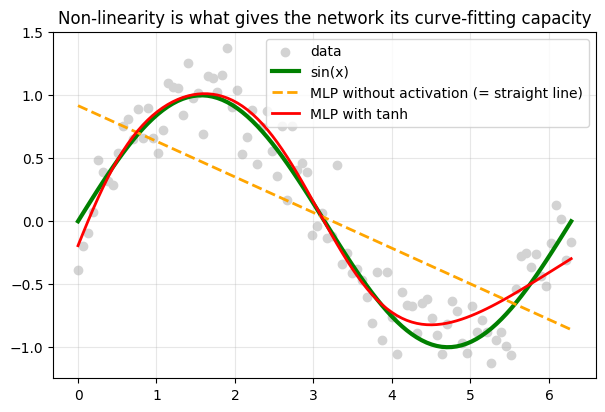

In [5]:
order = np.argsort(x)
_, y_hat_no_activation = forward(X, result_no_activation.weights, identity_activation)
_, y_hat_tanh = forward(X, result_tanh.weights)

plt.scatter(x, y_flat, color="lightgray", label="data", zorder=1)
plt.plot(x[order], np.sin(x[order]), color="green", lw=3, label="sin(x)", zorder=2)
plt.plot(x[order], y_hat_no_activation[order], color="orange", lw=2, ls="--", label="MLP without activation (= straight line)", zorder=3)
plt.plot(x[order], y_hat_tanh[order], color="red", lw=2, label="MLP with tanh", zorder=3)
plt.legend()
plt.grid(alpha=0.3)
plt.title("Non-linearity is what gives the network its curve-fitting capacity")
plt.show()


Without `tanh`, the "MLP" never leaves the world of straight lines — no
matter how many hidden neurons or training steps, it converges to the best
possible *linear* fit, and the SSE stays far above what `tanh` achieves. The
non-linearity is what lets the network bend and follow the sine's curve.


## Training

### Choosing the hyperparameters

- **`n_hidden = 6`**: number of hidden neurons used in the original script.
  Too few (2-3) can't capture the sine's curvature; too many (>15) increase
  the risk of overfitting on just 100 points.
- **`learning_rate = 0.01`**: with small-scale inputs and a saturating
  (tanh) activation, this rate converges stably without oscillating.
- **`n_steps = 100,000`**: plain gradient descent (no momentum/Adam) needs
  many iterations to fully converge; the convergence plot below shows the
  SSE stabilizing well before the limit.

### Why can the learning rate be 100x larger than in algorithm 1?

Two compounding reasons, both verifiable from the data and the code:

- **Smaller data scale**: here `x` ranges only from 0 to ~6.28 (2π) and `y`
  from about -1.1 to 1.4 — much smaller than algorithm 1's `Experience`
  (0 to 29). Smaller inputs mean smaller raw gradients.
- **Gradient normalization**: unlike algorithm 1, this code divides the
  gradient by `n_train` before updating the weights (`grad_w1 / n_train`).
  That's *not* the same as normalizing the training data — the data itself
  keeps its original scale — it's the **update step** that gets shrunk,
  which behaves like using the *average* gradient per sample instead of the
  *raw sum*.

This isn't unlimited safety, though — it just raises the ceiling. A quick
check: `lr=0.01` stays stable, but pushing it to `lr=1.0` already diverges
to `NaN` in a couple thousand steps.


In [6]:
result = train_mlp(X, y, n_hidden=6, learning_rate=0.01, n_steps=100_000, seed=42)
print(f"Final SSE: {result.loss_history[-1]:.4f}")


Final SSE: 3.9999


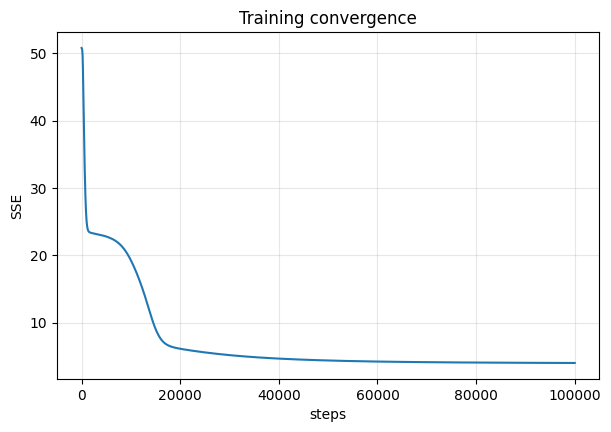

In [7]:
plt.plot(result.loss_history, color="tab:blue")
plt.xlabel("steps")
plt.ylabel("SSE")
plt.title("Training convergence")
plt.grid(alpha=0.3)
plt.show()


## Fit result

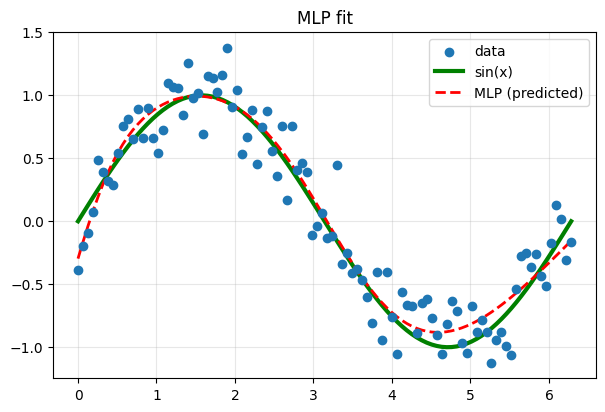

In [8]:
_, y_hat = forward(X, result.weights)

plt.scatter(x, y_flat, color="tab:blue", label="data", zorder=3)
plt.plot(x[order], np.sin(x[order]), color="green", lw=3, label="sin(x)")
plt.plot(x[order], y_hat[order], color="red", lw=2, ls="--", label="MLP (predicted)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP fit")
plt.show()


## Interpreting the metrics

RMSE and R² measure how close the network's output is to the *observed*
data (not to the noise-free target function, which isn't available in a
real problem). An R² close to 1 and a low RMSE (close to the injected
noise's standard deviation) indicate the MLP captured the sine shape
without excessively memorizing noise.


In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


print(f"RMSE: {rmse(y_flat, y_hat.flatten()):.5f}")
print(f"R2  : {r_squared(y_flat, y_hat.flatten()):.5f}")


RMSE: 0.20000
R2  : 0.92128


## Conclusion

The manually implemented MLP reproduces the sine's non-linear behavior from
a single tanh-activated hidden layer — and, as shown above, it genuinely
needs that non-linearity to do so; without it, it's just linear regression
in disguise. The next notebook (`03-MLP-Sklearn/`) solves the same problem
using a library (`scikit-learn`), equivalent to R's `neuralnet` package,
removing the need to derive backpropagation by hand.
